# Predicting House Prices with Machine Learning
### AI Literacy Project Taster Day — Queen Mary University of London

---

Welcome! Today you'll build a **machine learning model** that can predict the price of a house based on its features — just like the algorithms used by Zoopla and Rightmove.

By the end of this notebook you will have:
- Explored a real-world dataset using Python
- Trained a Linear Regression model from scratch
- Tested your model on houses it has **never seen before**
- Predicted the price of your *own* dream house
- 🇬🇧 **Retrained the model on London house prices** and compared the results

**No prior Python experience needed** — read the explanations carefully and run each cell in order (press `Shift + Enter`).

---
> 💡 **How to run a cell:** Click on it, then press **Shift + Enter**. A number will appear in the brackets `[ ]` to show it has run.


---
## Section 1 — What is Machine Learning? 🤖

**Machine learning** is a way of teaching a computer to find patterns in data — without programming the rules by hand.

Instead of writing: *"If the house has 4 bedrooms AND is in a nice area THEN add £200,000..."*  
...we show the computer **thousands of examples** and let it figure out the pattern itself.

### The type of ML we'll use today: Supervised Learning

We give the model:
- **Inputs (features):** things we know about a house — number of rooms, age, location...
- **Output (target):** the house price we want to predict

The model learns a mathematical relationship between inputs and output:

$$\text{House Price} = w_1 \times \text{Income} + w_2 \times \text{Rooms} + w_3 \times \text{Age} + \ldots + b$$

This is called **Linear Regression** — you may have seen the simpler version $y = mx + c$ in Maths!

The computer's job is to find the best values of $w_1, w_2, w_3 \ldots$ (called **weights**) and $b$ (the **intercept**).

---


## Section 2 — Loading Our Tools 🛠️

Before we start, we need to import the Python **libraries** we'll use.  
Think of these like apps on your phone — we need to open them before we can use them.

| Library | What it does |
|---------|-------------|
| `pandas` | Handles tables of data (like Excel, but in Python) |
| `numpy` | Fast maths on large lists of numbers |
| `matplotlib` / `seaborn` | Draw charts and graphs |
| `sklearn` | Contains our machine learning tools |


In [1]:
# ── Import our tools ───────────────────────────────────────────────────────────
import pandas as pd                          # for working with data tables
import numpy as np                           # for number crunching
import matplotlib.pyplot as plt              # for drawing graphs
import seaborn as sns                        # for nicer-looking graphs

from sklearn.model_selection import train_test_split   # split data into train/test
from sklearn.preprocessing import StandardScaler       # rescale our numbers
from sklearn.linear_model import LinearRegression      # our ML model
from sklearn.metrics import mean_squared_error, r2_score  # measuring accuracy

import warnings
warnings.filterwarnings('ignore')            # hide unimportant warning messages

# Make plots look nice
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

print("✅ All tools loaded successfully!")


✅ All tools loaded successfully!


---
## Section 3 — Meet the Data 📊

Our dataset contains information about **2,000 neighbourhoods in California**, USA.  
For each neighbourhood we know 8 things (features), plus the average house price.

| Column | What it means |
|--------|--------------|
| `MedInc` | Median household income in the area (in tens of thousands of dollars) |
| `HouseAge` | Average age of houses in years |
| `AveRooms` | Average number of rooms per house |
| `AveBedrms` | Average number of bedrooms per house |
| `Population` | Number of people living in the neighbourhood |
| `AveOccup` | Average number of people per household |
| `Latitude` | How far north/south the neighbourhood is |
| `Longitude` | How far east/west the neighbourhood is |
| `HouseValue` | **This is what we want to predict** — average house price in USD |

Let's load the data and take a look.


In [2]:
# ── Load the California housing dataset ───────────────────────────────────────
df = pd.read_csv("california_housing.csv")

print(f"Our dataset has {df.shape[0]} rows (neighbourhoods) and {df.shape[1]} columns (features)")
print()
df.head(10)   # show the first 10 rows


Our dataset has 2000 rows (neighbourhoods) and 9 columns (features)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,6.037732,21.762431,7.643597,0.878729,285.288856,4.656681,34.434662,-117.329985,438409.335861
1,4.124899,4.366502,6.668654,0.998419,1221.637642,2.570517,38.617981,-123.202030,210062.656960
2,6.610195,18.789847,10.237641,0.798455,312.467704,5.619109,41.947798,-115.484489,411796.782056
3,11.176551,6.660903,2.293167,1.253061,600.650567,5.302762,32.614087,-123.444528,567026.681561
4,3.894277,42.219996,8.044390,1.549973,2826.923075,3.163120,37.638738,-122.512585,269581.864379
5,3.894315,49.332089,7.807526,0.500000,343.492667,2.397142,37.949833,-118.232103,229612.818771
6,11.559732,4.688140,3.355904,1.263775,137.966478,1.847043,41.184984,-116.605885,564383.747502
7,7.102599,49.710876,7.514980,0.989331,232.166041,2.948269,37.307051,-123.237484,353747.068036
8,3.381486,27.651407,6.105904,1.145358,1797.763779,3.994344,37.665163,-114.792352,292565.520170
9,6.206121,16.277850,4.922300,1.283598,858.109005,2.554641,36.980702,-114.263924,385287.742821


In [4]:
# ── Summary statistics ─────────────────────────────────────────────────────────
# This gives us the min, max, average, etc. for each column
print("Summary statistics for each column:\n")
df.describe().round(2)


Summary statistics for each column:



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,5.50,26.03,5.33,1.10,1114.24,3.33,37.23,-118.85,322177.41
std,3.63,14.63,2.04,0.39,1403.71,1.69,2.73,2.83,155138.23
min,0.64,1.00,1.00,0.50,14.34,1.00,32.50,-123.99,50000.00
25%,3.08,13.40,3.96,0.80,351.58,2.15,34.89,-121.22,211520.83
50%,4.60,25.97,5.36,1.08,674.06,2.96,37.26,-118.73,289555.56
75%,6.75,38.44,6.73,1.37,1331.46,4.08,39.59,-116.49,399677.52
max,45.22,51.98,12.21,2.51,19484.66,16.26,42.00,-114.01,800000.00


> 💬 **Questions to think about:**
> - What is the cheapest house value in the dataset? What is the most expensive?
> - What is the average number of rooms per house?
> - Does anything look surprising to you?


---
## Section 4 — Exploring the Data 🔍

Before training any model, we always **explore the data visually** first.  
This helps us understand what patterns might exist and spot anything unusual.

### 4a — How are house prices distributed?

Let's start with a simple question: **what do house prices look like?**


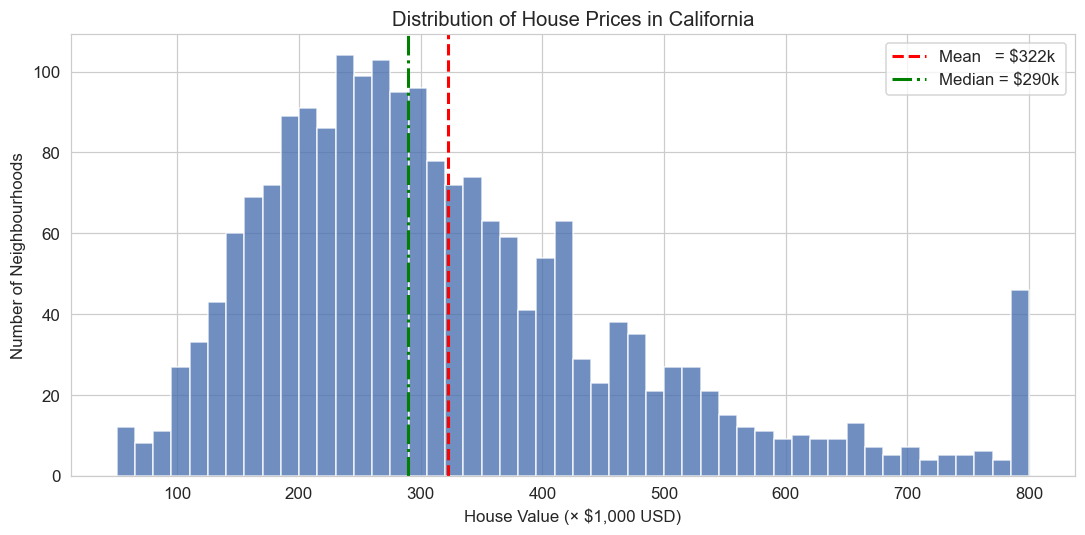

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df["HouseValue"] / 1000, bins=50, color="#4C72B0",
        alpha=0.8, edgecolor="white")
ax.axvline(df["HouseValue"].mean()   / 1000, color="red",   linestyle="--",
           lw=2, label=f"Mean   = ${df['HouseValue'].mean()/1000:,.0f}k")
ax.axvline(df["HouseValue"].median() / 1000, color="green", linestyle="-.",
           lw=2, label=f"Median = ${df['HouseValue'].median()/1000:,.0f}k")

ax.set_xlabel("House Value (× $1,000 USD)")
ax.set_ylabel("Number of Neighbourhoods")
ax.set_title("Distribution of House Prices in California")
ax.legend()
plt.tight_layout()
plt.show()


> 💬 **Notice:** The distribution is **skewed to the right** — most houses are in the middle price range, but a small number of very expensive houses pull the average (mean) upward. This is why the **median** is often a better measure of a "typical" house price.

---
### 4b — Does income predict house price?

Intuitively, wealthier neighbourhoods should have more expensive houses.  
Let's check if the data agrees.


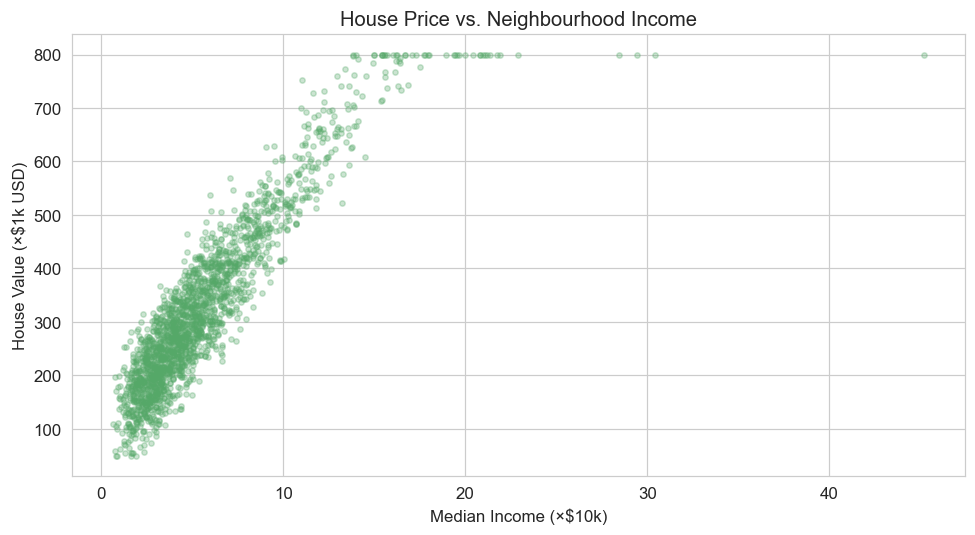

 Correlation between income and house price: r = 0.909

Interpretation guide:
  r close to +1 → strong positive relationship
  r close to  0 → no relationship
  r close to -1 → strong negative relationship


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df["MedInc"], df["HouseValue"] / 1000,
           alpha=0.3, s=12, color="#55A868")
ax.set_xlabel("Median Income (×$10k)")
ax.set_ylabel("House Value (×$1k USD)")
ax.set_title("House Price vs. Neighbourhood Income")
plt.tight_layout()
plt.show()

# Calculate the Pearson correlation coefficient
correlation = df["MedInc"].corr(df["HouseValue"])
print(f" Correlation between income and house price: r = {correlation:.3f}")
print()
print("Interpretation guide:")
print("  r close to +1 → strong positive relationship")
print("  r close to  0 → no relationship")
print("  r close to -1 → strong negative relationship")


> 💬 **What does the correlation value tell us?**  
> A value close to **+1** means "as income goes up, house price goes up too" — which is exactly what we'd expect!

---
### 4c — Which features are most related to house price?

Let's check all features at once using a **correlation heatmap**.  
Darker red = stronger positive relationship. Darker blue = stronger negative relationship.


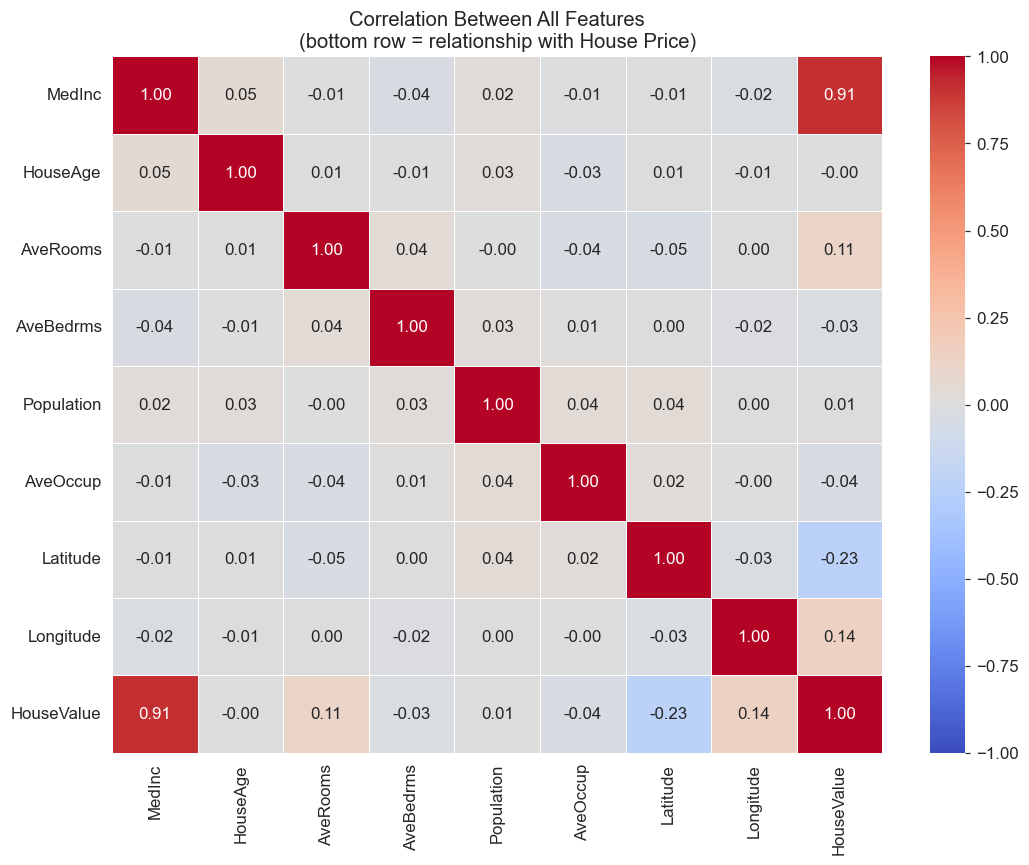

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df.corr()
sns.heatmap(
    corr,
    annot=True,     # show the numbers
    fmt=".2f",      # 2 decimal places
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
    vmin=-1, vmax=1
)
ax.set_title("Correlation Between All Features\n(bottom row = relationship with House Price)")
plt.tight_layout()
plt.show()


> **Look at the bottom row** (HouseValue). Which feature has the **strongest** relationship with house price?  
> Which feature is **negatively** correlated — meaning as it increases, house price tends to decrease?


---
## Section 5 — Preparing the Data

Before training our model, we need to do two things:

### Step 1 — Split into Training and Test sets

We **never** show the model all the data before testing it — that would be like giving a student the answers before an exam!

Instead, we split the data:
- **80% Training set** — the model learns from this
- **20% Test set** — we use this to check how well the model performs on houses it has *never seen*


In [10]:
# Define which columns are our inputs (X) and which is our target (y)
FEATURES = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
            "Population", "AveOccup", "Latitude", "Longitude"]
TARGET   = "HouseValue"

X = df[FEATURES]
y = df[TARGET]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set   : {len(X_train)} neighbourhoods  ← model learns from these")
print(f"Test set       : {len(X_test)} neighbourhoods   ← model is tested on these")
print()
print("✅ The model will NEVER see the test set during training.")


Training set   : 1600 neighbourhoods  ← model learns from these
Test set       : 400 neighbourhoods   ← model is tested on these

✅ The model will NEVER see the test set during training.


### Step 2 — Rescale the Features (Standardisation)

Our features are on very different scales:
- `MedInc` ranges from about 1 to 15
- `Population` ranges from hundreds to thousands

If we don't rescale, the model might think Population is more important *just because its numbers are bigger*.  
**Standardisation** rescales everything so that each feature has a mean of 0 and a standard deviation of 1.

$$x_{\text{scaled}} = \frac{x - \text{mean}}{\text{standard deviation}}$$


In [11]:
# Rescale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn the scale from training data...
X_test_scaled  = scaler.transform(X_test)         # ...then apply the same scale to test data

print("✅ Features rescaled.")
print()
print("Example — first training sample BEFORE and AFTER scaling:")
print(f"  Before: {X_train.iloc[0].values.round(2)}")
print(f"  After : {X_train_scaled[0].round(2)}")


✅ Features rescaled.

Example — first training sample BEFORE and AFTER scaling:
  Before: [   4.37    5.34    4.27    1.37  605.53    2.85   37.67 -118.94]
  After : [-0.3  -1.41 -0.53  0.69 -0.35 -0.27  0.15 -0.02]


---
## Section 6 — Training the Model

Now the exciting part — we train our **Linear Regression** model.

The model learns an equation of the form:

$$\text{Price} = w_1 \times \text{Income} + w_2 \times \text{Rooms} + \ldots + b$$

It finds the best values of $w_1, w_2, \ldots$ by **minimising the error** between its predictions and the real prices in the training set.

This all happens in just **one line of code**:


In [12]:
# Train the model — this is where the "learning" happens!
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("✅ Model trained!")
print()

# Show the weights (coefficients) the model learned
coef_df = pd.DataFrame({
    "Feature"    : FEATURES,
    "Weight (w)" : model.coef_.round(0).astype(int),
}).sort_values("Weight (w)", ascending=False).reset_index(drop=True)

print("📊 What the model learned — weights for each feature:")
print()
print(coef_df.to_string(index=False))
print()
print(f"Intercept (b) = ${model.intercept_:,.0f}")


✅ Model trained!

📊 What the model learned — weights for each feature:

   Feature  Weight (w)
    MedInc      140164
 Longitude       23365
  AveRooms       17135
 AveBedrms        1639
Population        -543
  AveOccup       -3082
  HouseAge       -7214
  Latitude      -31909

Intercept (b) = $319,167


> 💬 **How to read the weights:**
> - A **large positive weight** means "this feature strongly *increases* the predicted price"
> - A **large negative weight** means "this feature strongly *decreases* the predicted price"
> - A weight close to **zero** means the feature has little influence
>
> Does the most important feature match what you found in the correlation heatmap?


---
## Section 7 — How Well Did We Do? 📏

Now we test the model on the **20% of data it has never seen**.

We use two measures of accuracy:

| Metric | What it means | Better when... |
|--------|--------------|----------------|
| **RMSE** (Root Mean Squared Error) | Average error in dollars — how far off is our prediction on a typical house? | Lower is better |
| **R² Score** | How much of the variation in price does our model explain? (0 = nothing, 1 = perfect) | Closer to 1 is better |


In [13]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate accuracy metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("📊 Model Performance on Test Data")
print("="*40)
print(f"  Average prediction error (RMSE) : ${rmse:,.0f}")
print(f"  R² Score                        : {r2:.3f}")
print()

if r2 > 0.7:
    print("💚 Good result! The model explains most of the variation in house prices.")
elif r2 > 0.5:
    print("🟡 Reasonable result — but there's room for improvement.")
else:
    print("🔴 The model is struggling — we might need more features or a different approach.")


📊 Model Performance on Test Data
  Average prediction error (RMSE) : $51,381
  R² Score                        : 0.899

💚 Good result! The model explains most of the variation in house prices.


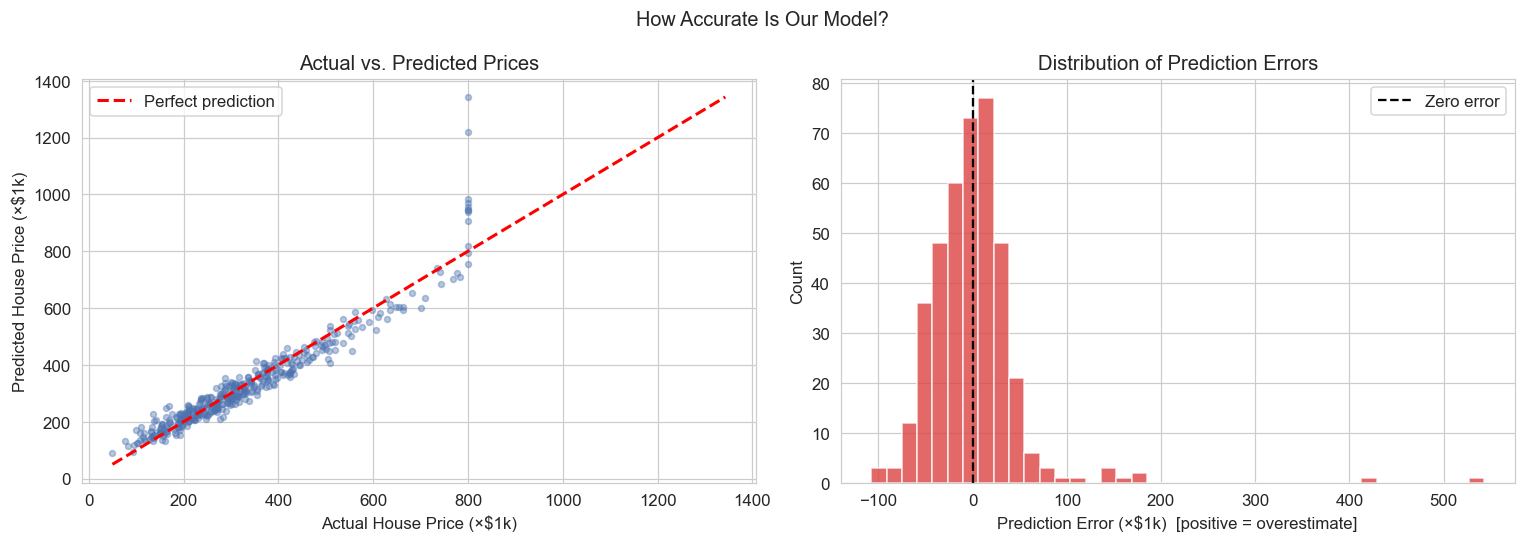

Our model was within ±$51k on average.


In [14]:
# ── Actual vs Predicted plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test / 1e3, y_pred / 1e3, alpha=0.4, s=15, color="#4C72B0")
min_val = min(y_test.min(), y_pred.min()) / 1e3
max_val = max(y_test.max(), y_pred.max()) / 1e3
axes[0].plot([min_val, max_val], [min_val, max_val],
             "r--", lw=2, label="Perfect prediction")
axes[0].set_xlabel("Actual House Price (×$1k)")
axes[0].set_ylabel("Predicted House Price (×$1k)")
axes[0].set_title("Actual vs. Predicted Prices")
axes[0].legend()

# Plot 2: How big were our errors?
errors = (y_pred - y_test.values) / 1e3
axes[1].hist(errors, bins=40, color="#DD4444", alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", lw=1.5, label="Zero error")
axes[1].set_xlabel("Prediction Error (×$1k)  [positive = overestimate]")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Prediction Errors")
axes[1].legend()

plt.suptitle("How Accurate Is Our Model?", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Our model was within ±${rmse/1000:.0f}k on average.")


> 💬 **Reading the plots:**
> - **Left plot:** if every prediction were perfect, all points would sit exactly on the red dashed line. Points scattered around it show our errors.
> - **Right plot:** errors centred around zero is good — it means we're not *systematically* over- or under-estimating.

---


---
## Section 8 — 🏠 Predict Your Own House!

Now it's **your turn**. Edit the values in the cell below to describe your dream neighbourhood in California and see what price the model predicts.

**Instructions:** Change the numbers after each `=` sign. Don't change anything else!


In [15]:
# ═══════════════════════════════════════════════════════════════
#  ✏️  CHANGE THESE VALUES TO DESCRIBE YOUR DREAM NEIGHBOURHOOD
# ═══════════════════════════════════════════════════════════════

median_income      = 8.0    # neighbourhood income in ×$10k  (try 2.0 to 15.0)
house_age          = 10.0   # average age of houses in years  (try 1 to 50)
average_rooms      = 7.0    # average rooms per house         (try 3 to 12)
average_bedrooms   = 2.0    # average bedrooms per house      (try 1 to 5)
population         = 1000   # number of people nearby         (try 500 to 5000)
average_occupancy  = 2.5    # people per household            (try 1 to 6)
latitude           = 34.0   # 34 = Los Angeles, 37 = San Francisco
longitude          = -118.2 # -118 = LA, -122 = SF

# ═══════════════════════════════════════════════════════════════
#  Run this cell to get your prediction (Shift + Enter)
# ═══════════════════════════════════════════════════════════════

my_house = pd.DataFrame([[
    median_income, house_age, average_rooms, average_bedrooms,
    population, average_occupancy, latitude, longitude
]], columns=FEATURES)

my_house_scaled    = scaler.transform(my_house)
predicted_price    = model.predict(my_house_scaled)[0]

print("🏠 Your neighbourhood description:")
print(f"   Median income   : ${median_income * 10_000:,.0f}/year")
print(f"   House age       : {house_age:.0f} years")
print(f"   Average rooms   : {average_rooms:.0f}")
print(f"   Average bedrooms: {average_bedrooms:.0f}")
print(f"   Population      : {population:,}")
print()
print(f"💰 Predicted house price: ${predicted_price:,.0f}")


🏠 Your neighbourhood description:
   Median income   : $80,000/year
   House age       : 10 years
   Average rooms   : 7
   Average bedrooms: 2
   Population      : 1,000

💰 Predicted house price: $492,396


> 🎯 **Challenge:** Can you find the combination of features that produces the **highest** predicted price?  
> What about the **lowest**? Does the model's reasoning match your intuition?


---
---
## 🇬🇧 London Extension — Retrain on London House Prices

California is interesting, but you live in **London** — one of the most expensive housing markets in the world!

In this extension we'll:
1. Load a dataset of London house prices by borough
2. Retrain **the exact same type of model** on this new data
3. Compare what the model learns about London vs California
4. Predict the price of a London home you choose

---

### The London Dataset

Our London dataset contains **1,500 property sales** with the following features:

| Column | What it means |
|--------|--------------|
| `Borough` | Which London borough the property is in |
| `Bedrooms` | Number of bedrooms |
| `Bathrooms` | Number of bathrooms |
| `FloorArea` | Size of the property in m² |
| `PropertyAge` | When the property was built (e.g. Pre-1900, Post-2000) |
| `Price` | 🎯 Sale price in £ — what we want to predict |


In [17]:
# ── Load London data ───────────────────────────────────────────────────────────
df_lon = pd.read_csv("london_housing.csv")

print(f"London dataset: {df_lon.shape[0]} properties, {df_lon.shape[1]} features")
print()
df_lon.head(8)


London dataset: 1500 properties, 6 features



,Borough,Bedrooms,Bathrooms,FloorArea,PropertyAge,Price
0,Wandsworth,3,2,101.6,Pre-1900,1037062
1,Wandsworth,2,1,64.5,1950-1980,820588
2,Haringey,1,1,32.5,1950-1980,627429
3,Greenwich,3,2,91.6,1980-2000,867301
4,Greenwich,2,1,56.9,Pre-1900,812640
5,Ealing,3,2,83.1,1980-2000,850715
6,Camden,4,2,133.6,1950-1980,1324555
7,Ealing,2,1,79.4,1950-1980,862063


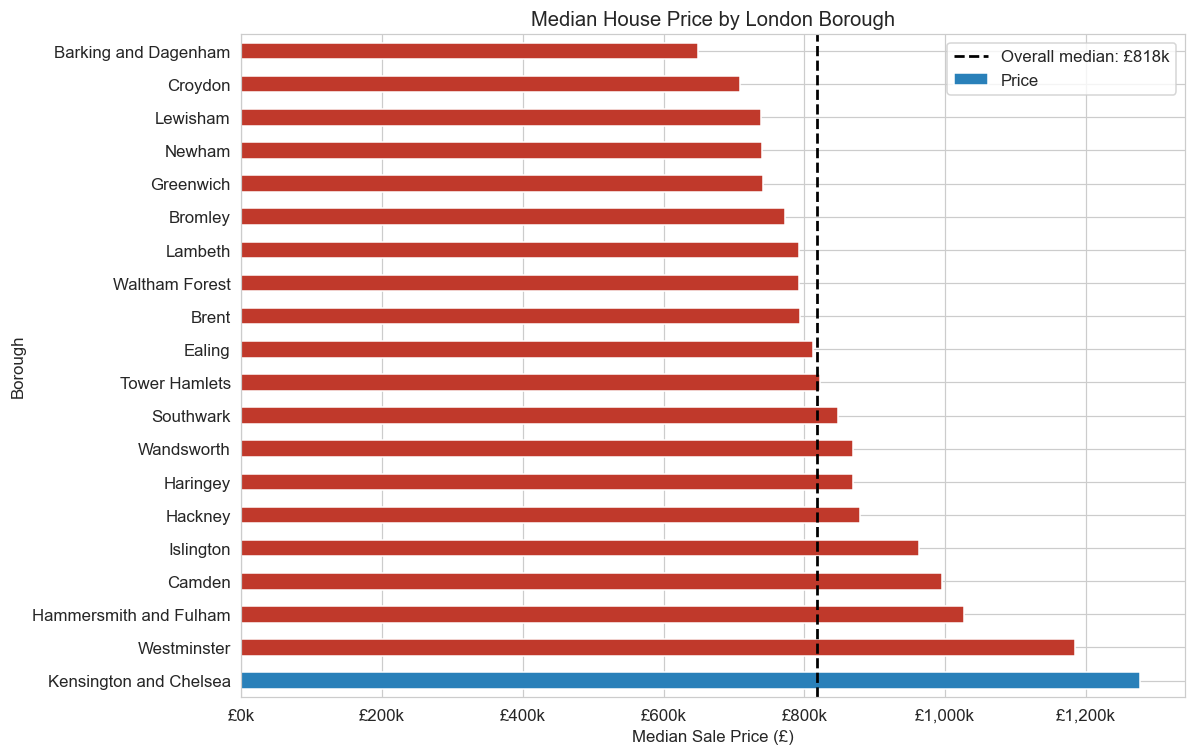

In [18]:
# ── Average price by borough ───────────────────────────────────────────────────
borough_median = (
    df_lon.groupby("Borough")["Price"]
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#C0392B" if p > 700000 else "#2980B9" if p > 500000 else "#27AE60"
          for p in borough_median.values]
borough_median.plot(kind="barh", ax=ax, color=colors[::-1], edgecolor="white")
ax.axvline(borough_median.median(), color="black", linestyle="--",
           lw=1.8, label=f"Overall median: £{borough_median.median()/1000:,.0f}k")
ax.set_xlabel("Median Sale Price (£)")
ax.set_title("Median House Price by London Borough")
ax.legend()
# Format x-axis as £k
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"£{v/1e3:,.0f}k")
)
plt.tight_layout()
plt.show()


> 💬 **Do these prices match your expectations?**  
> Kensington & Chelsea and Westminster are famously expensive — does the chart reflect that?  
> Which boroughs are most affordable?

---
### Handling Categories: One-Hot Encoding

Unlike the California dataset, our London data has **text columns** — `Borough` and `PropertyAge`.  
Computers can only work with numbers, so we need to convert these.

**One-Hot Encoding** creates a new column for each category with a 1 (yes) or 0 (no):

| Borough | ... | is_Camden | is_Hackney | is_Westminster | ... |
|---------|-----|-----------|------------|----------------|-----|
| Camden  | ... | 1         | 0          | 0              | ... |
| Hackney | ... | 0         | 1          | 0              | ... |


In [19]:
# ── One-hot encode Borough and PropertyAge ────────────────────────────────────
df_encoded = pd.get_dummies(df_lon, columns=["Borough", "PropertyAge"],
                             drop_first=True)   # drop first to avoid redundancy

# Our numeric features + all the new dummy columns
LONDON_FEATURES = [col for col in df_encoded.columns if col != "Price"]

print(f"Features after encoding: {len(LONDON_FEATURES)}")
print()
print("First few feature names:")
print(LONDON_FEATURES[:10])
print("...")


Features after encoding: 26

First few feature names:
['Bedrooms', 'Bathrooms', 'FloorArea', 'Borough_Brent', 'Borough_Bromley', 'Borough_Camden', 'Borough_Croydon', 'Borough_Ealing', 'Borough_Greenwich', 'Borough_Hackney']
...


In [22]:
# ── Train / Test split ─────────────────────────────────────────────────────────
X_lon = df_encoded[LONDON_FEATURES]
y_lon = df_encoded["Price"]

X_lon_train, X_lon_test, y_lon_train, y_lon_test = train_test_split(
    X_lon, y_lon, test_size=0.20, random_state=42
)

# ── Scale ──────────────────────────────────────────────────────────────────────
scaler_lon = StandardScaler()
X_lon_train_sc = scaler_lon.fit_transform(X_lon_train)
X_lon_test_sc  = scaler_lon.transform(X_lon_test)

print(f"Training set : {len(X_lon_train)} properties")
print(f"Test set     : {len(X_lon_test)} properties")
print()
print("✅ Data prepared.")


Training set : 1200 properties
Test set     : 300 properties

✅ Data prepared.


### Retrain the Model on London Data

We use **exactly the same model** — `LinearRegression()`. Only the data changes.  
This shows that the same algorithm can be applied to very different problems.


In [24]:
# ── Train London model ────────────────────────────────────────────────────────
model_lon = LinearRegression()
model_lon.fit(X_lon_train_sc, y_lon_train)

# ── Evaluate ───────────────────────────────────────────────────────────────────
y_lon_pred = model_lon.predict(X_lon_test_sc)

rmse_lon = np.sqrt(mean_squared_error(y_lon_test, y_lon_pred))
r2_lon   = r2_score(y_lon_test, y_lon_pred)

print("📊 London Model Performance on Test Data")
print("="*45)
print(f"  Average prediction error (RMSE) : £{rmse_lon:,.0f}")
print(f"  R² Score                        : {r2_lon:.3f}")


📊 London Model Performance on Test Data
  Average prediction error (RMSE) : £38,245
  R² Score                        : 0.967


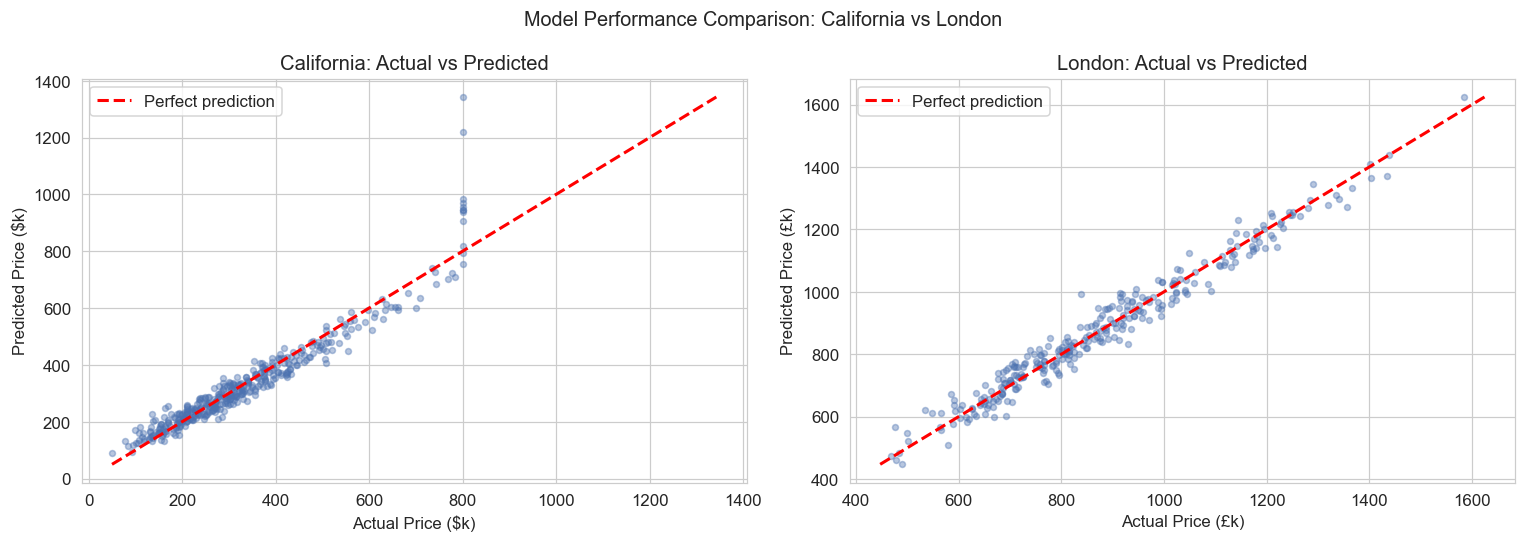

In [25]:
# ── Visual comparison of California vs London model performance ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_hat, label, currency in [
    (axes[0], y_test,     y_pred,     "California", "$"),
    (axes[1], y_lon_test, y_lon_pred, "London",     "£"),
]:
    ax.scatter(y_true / 1e3, y_hat / 1e3, alpha=0.4, s=15, color="#4C72B0")
    lo = min(y_true.min(), y_hat.min()) / 1e3
    hi = max(y_true.max(), y_hat.max()) / 1e3
    ax.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect prediction")
    ax.set_xlabel(f"Actual Price ({currency}k)")
    ax.set_ylabel(f"Predicted Price ({currency}k)")
    ax.set_title(f"{label}: Actual vs Predicted")
    ax.legend()

plt.suptitle("Model Performance Comparison: California vs London", fontsize=13)
plt.tight_layout()
plt.show()


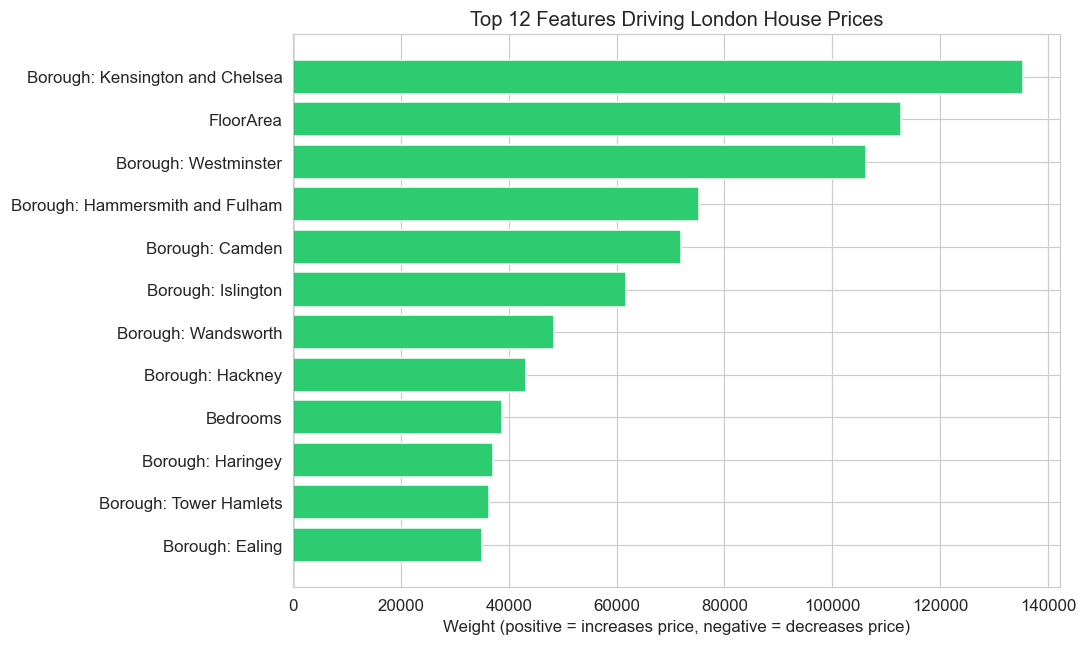

In [26]:
# ── Top features driving London house prices ──────────────────────────────────
lon_coef_df = pd.DataFrame({
    "Feature": LONDON_FEATURES,
    "Weight" : model_lon.coef_
}).reindex(
    pd.Series(model_lon.coef_).abs().sort_values(ascending=False).index
).head(12).reset_index(drop=True)

# Clean up feature names for display
lon_coef_df["Feature"] = (
    lon_coef_df["Feature"]
    .str.replace("Borough_", "Borough: ", regex=False)
    .str.replace("PropertyAge_", "Age: ", regex=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ECC71" if w > 0 else "#E74C3C" for w in lon_coef_df["Weight"]]
ax.barh(lon_coef_df["Feature"][::-1], lon_coef_df["Weight"][::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Weight (positive = increases price, negative = decreases price)")
ax.set_title("Top 12 Features Driving London House Prices")
plt.tight_layout()
plt.show()


> 💬 **Compare with California:**
> - In California, **income** was the dominant driver.
> - In London, how important is **floor area** vs **borough** vs **number of bedrooms**?
> - Does the **age** of a property help or hurt its value in London?


---
## Section 10 — 🏙️ Predict a London House Price!

Now use the London model to predict the price of a property **you design**.  
Edit the values below — try to replicate your own home, or design your dream London flat!


In [27]:
# ── Available boroughs ────────────────────────────────────────────────────────
all_boroughs = sorted(df_lon["Borough"].unique())
print("Available boroughs:")
for i, b in enumerate(all_boroughs, 1):
    print(f"  {i:2}. {b}")


Available boroughs:
   1. Barking and Dagenham
   2. Brent
   3. Bromley
   4. Camden
   5. Croydon
   6. Ealing
   7. Greenwich
   8. Hackney
   9. Hammersmith and Fulham
  10. Haringey
  11. Islington
  12. Kensington and Chelsea
  13. Lambeth
  14. Lewisham
  15. Newham
  16. Southwark
  17. Tower Hamlets
  18. Waltham Forest
  19. Wandsworth
  20. Westminster


In [28]:
# ═══════════════════════════════════════════════════════════════
#  ✏️  CHANGE THESE VALUES TO DESCRIBE YOUR LONDON PROPERTY
# ═══════════════════════════════════════════════════════════════

my_borough    = "Hackney"       # copy a borough name from the list above
my_bedrooms   = 2               # number of bedrooms     (1 to 5)
my_bathrooms  = 1               # number of bathrooms    (1 to 4)
my_floor_area = 65.0            # size in m²             (30 to 200)
my_age        = "Post-2000"     # choose from: Pre-1900, 1900-1950,
                                #   1950-1980, 1980-2000, Post-2000

# ═══════════════════════════════════════════════════════════════
#  Run this cell to get your prediction (Shift + Enter)
# ═══════════════════════════════════════════════════════════════

# Build a single-row DataFrame matching the training structure
base_row = {col: 0 for col in LONDON_FEATURES}
base_row["Bedrooms"]   = my_bedrooms
base_row["Bathrooms"]  = my_bathrooms
base_row["FloorArea"]  = my_floor_area

borough_col_name = f"Borough_{my_borough}"
age_col_name     = f"PropertyAge_{my_age}"

if borough_col_name in base_row:
    base_row[borough_col_name] = 1
if age_col_name in base_row:
    base_row[age_col_name] = 1

my_london_house = pd.DataFrame([base_row])
my_london_house_sc = scaler_lon.transform(my_london_house)
lon_predicted_price = model_lon.predict(my_london_house_sc)[0]

print("🏙️  Your London property:")
print(f"   Borough     : {my_borough}")
print(f"   Bedrooms    : {my_bedrooms}")
print(f"   Bathrooms   : {my_bathrooms}")
print(f"   Floor area  : {my_floor_area:.0f} m²")
print(f"   Property age: {my_age}")
print()
print(f"💰 Predicted sale price: £{lon_predicted_price:,.0f}")
print()

# Compare to borough median
b_median = df_lon[df_lon["Borough"] == my_borough]["Price"].median()
diff     = lon_predicted_price - b_median
sign     = "above" if diff > 0 else "below"
print(f"📊 The median price in {my_borough} is £{b_median:,.0f}")
print(f"   Your property is £{abs(diff):,.0f} ({sign} the borough median)")


🏙️  Your London property:
   Borough     : Hackney
   Bedrooms    : 2
   Bathrooms   : 1
   Floor area  : 65 m²
   Property age: Post-2000

💰 Predicted sale price: £911,866

📊 The median price in Hackney is £879,703
   Your property is £32,163 (above the borough median)


---
## Section 11 — Discussion & Further Thinking 💬

Congratulations — you've built and deployed **two machine learning models**!

### Questions to discuss with your group:

1. **Model accuracy:** Our model makes errors of tens of thousands of pounds on average. Why might it be difficult to predict house prices exactly, even with a perfect algorithm?

2. **Missing features:** What information about a house *isn't* in our dataset that would probably affect the price? (Think about things like proximity to a Tube station, school quality, crime rates...)

3. **California vs London:** The same algorithm was applied to two very different markets. What was the most important feature in each case? Why might they differ?

4. **Fairness:** If a bank used an ML model to decide whether to give someone a mortgage, and the model had learned that certain boroughs are "risky" — what ethical problems could this cause?

5. **Limitations of Linear Regression:** Our model assumes the relationship between features and price is a *straight line*. Can you think of cases where that might not be true? (Hint: does adding a 10th bedroom increase price as much as adding a 2nd?)

---

### What comes next in ML?

If you enjoyed today, here are some topics to explore:

| Topic | What it is |
|-------|-----------|
| **Decision Trees & Random Forests** | Models that learn "if/then" rules — often more accurate than linear regression |
| **Neural Networks** | Loosely inspired by the brain; power tools like ChatGPT and image recognition |
| **Cross-Validation** | A smarter way to test models than a single 80/20 split |
| **Feature Engineering** | Creating new features (like "distance to nearest Tube station") to improve models |

---

### Want to learn more?

- 🌐 **Kaggle** (kaggle.com) — free datasets and ML competitions
- 📚 **fast.ai** — free, practical deep learning course for beginners

---
*Notebook developed for the QMUL A-Level Taster Day · Department of Chemistry*
